In [1]:
# Chạy ô này trước, chọn một file predictive_maintenance.csv từ máy bạn.
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Đã đọc {filename}: {df.shape[0]:,} dòng, {df.shape[1]} cột")
display(df.head())

Đã đọc predictive_maintenance.csv: 10,000 dòng, 10 cột


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


# Phần A — Dự đoán máy hỏng bằng Dense Neural Network

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from IPython.display import display, Markdown

SEED = 42  # Giữ cố định phép chia dữ liệu và khởi tạo mạng để dễ chạy lại.
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Khảo sát dữ liệu: missing và độ lệch của nhãn

,Kiểu dữ liệu,Số missing,Tỷ lệ missing (%),Số giá trị duy nhất
UDI,int64,0,0.0,10000
Product ID,str,0,0.0,10000
Type,str,0,0.0,3
Air temperature [K],float64,0,0.0,93
Process temperature [K],float64,0,0.0,82
Rotational speed [rpm],int64,0,0.0,941
Torque [Nm],float64,0,0.0,577
Tool wear [min],int64,0,0.0,246
Target,int64,0,0.0,2
Failure Type,str,0,0.0,6


,Số mẫu,Tỷ lệ (%)
Target,,
0,9661,96.61
1,339,3.39


Tổng giá trị thiếu: 0
Tỷ lệ máy hỏng: 3.39%
Số mẫu không hỏng gấp 28.5 lần số mẫu hỏng.


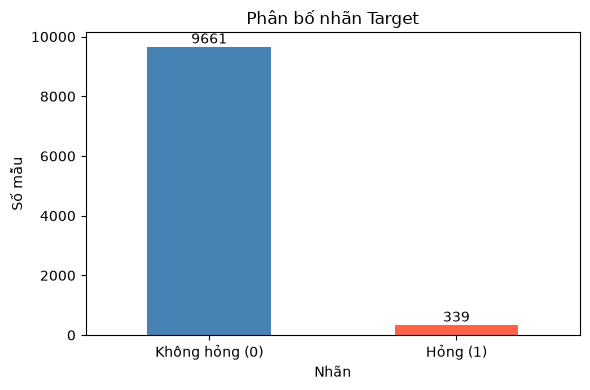

In [3]:
survey = pd.DataFrame({
    "Kiểu dữ liệu": df.dtypes.astype(str),
    "Số missing": df.isna().sum(),
    "Tỷ lệ missing (%)": df.isna().mean() * 100,
    "Số giá trị duy nhất": df.nunique(),
})
display(survey)

label_counts = df["Target"].value_counts().reindex([0, 1])
display(pd.DataFrame({"Số mẫu": label_counts, "Tỷ lệ (%)": label_counts / len(df) * 100}))
print(f"Tổng giá trị thiếu: {df.isna().sum().sum()}")
print(f"Tỷ lệ máy hỏng: {df['Target'].mean():.2%}")
print(f"Số mẫu không hỏng gấp {label_counts[0] / label_counts[1]:.1f} lần số mẫu hỏng.")

ax = label_counts.plot.bar(color=["steelblue", "tomato"], rot=0, figsize=(6, 4))
ax.set_xticklabels(["Không hỏng (0)", "Hỏng (1)"])
ax.set(title="Phân bố nhãn Target", xlabel="Nhãn", ylabel="Số mẫu")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

Dữ liệu có 10.000 mẫu, không có missing, trong đó chỉ 339 mẫu hỏng
(3,39%). Nhãn lệch nhiều về lớp không hỏng. Không cần thêm bước điền giá trị thiếu cho file này.
Một cột không thiếu dữ liệu vẫn có thể không hợp lệ làm đầu vào nếu chỉ được ghi nhận sau sự cố.

## 2. Loại biến định danh và thông tin tiết lộ kết quả

| Cột | Quyết định và lý do |
|---|---|
| `UDI` | Bỏ: số định danh của dòng, không mô tả trạng thái vận hành. |
| `Product ID` | Bỏ: mã sản phẩm; mạng có thể học liên hệ theo mã thay vì điều kiện vận hành. Thông tin loại sản phẩm đã có ở `Type`. |
| `Failure Type` | Bỏ khỏi đầu vào: lý do/loại lỗi mô tả kết quả sự cố, thường chỉ biết khi đã xảy ra lỗi. |
| `Target` | Tách riêng làm nhãn y, không cho vào đầu vào X. |
| `Type` và 5 cột đo vận hành | Giữ làm đầu vào, giả định đã biết/đo được khi dự đoán. |


**Target-derived feature** là feature được tạo từ nhãn hoặc chứa thông tin về kết quả cần
dự đoán. `Failure Type` thuộc nhóm thông tin tiết lộ kết quả: nếu biết một máy có lỗi nguồn,
gần như đã biết máy đó hỏng. Đưa cột này vào sẽ khiến mô hình được nhìn thông tin về đáp án.


In [ ]:
display(pd.crosstab(df["Failure Type"], df["Target"]))
guess_from_failure_type = (df["Failure Type"] != "No Failure").astype(int)
print(f"Biết loại lỗi thật rồi đoán hỏng/không hỏng: khớp {(guess_from_failure_type == df['Target']).mean():.2%} số dòng.")
print("Số dòng không khớp quy tắc này:", (guess_from_failure_type != df["Target"]).sum())

clean_data = df.drop(columns=["UDI", "Product ID", "Failure Type"])
X = clean_data.drop(columns="Target")
y = clean_data["Target"]
display(X.head())
print("Các feature được dùng:", X.columns.tolist())
print("Shape X:", X.shape, "| Shape y:", y.shape)

Target,0,1
Failure Type,,
Heat Dissipation Failure,0,112
No Failure,9643,9
Overstrain Failure,0,78
Power Failure,0,95
Random Failures,18,0
Tool Wear Failure,0,45


Biết loại lỗi thật rồi đoán hỏng/không hỏng: khớp 99.73% số dòng.
Số dòng không khớp quy tắc này: 27
Đây chỉ là minh họa thông tin tiết lộ đáp án, không phải đánh giá một model hợp lệ.


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


Các feature được dùng: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Shape X: (10000, 6) | Shape y: (10000,)


## 3. Chia train/validation và chuẩn bị đầu vào cho NN


Chia ngẫu nhiên **80% train / 20% validate**: phần lớn mẫu dành cho học, phần còn lại dành cho đánh giá.
`stratify=y` giữ tỷ lệ hỏng/không hỏng gần nhau ở hai tập. 

Mã hóa `Type` thành ba cột 0/1 cho L/M/H (one-hot) Chuẩn hóa năm cột số
bằng trung bình và độ lệch chuẩn chỉ tính trên train, rồi dùng lại cho dev để tránh data-leakage.
Sau xử lý, mỗi mẫu có 8 đầu vào: 5 cột số + 3 cột Type one-hot.

In [5]:
X_train, X_dev, y_train, y_dev = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED,
)
numeric_columns = X.select_dtypes(include="number").columns.tolist()
scaler = StandardScaler()
scaler.fit(X_train[numeric_columns])

def prepare_inputs(frame):
    numeric = scaler.transform(frame[numeric_columns])
    types = pd.get_dummies(frame["Type"]).reindex(columns=["L", "M", "H"], fill_value=0)
    values = np.column_stack([numeric, types.to_numpy()]).astype("float32")
    return torch.tensor(values)

X_train_tensor = prepare_inputs(X_train)
X_dev_tensor = prepare_inputs(X_dev)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_dev_tensor = torch.tensor(y_dev.to_numpy(), dtype=torch.float32).reshape(-1, 1)

display(pd.DataFrame({
    "Tập": ["Train", "Dev"],
    "Số mẫu": [len(y_train), len(y_dev)],
    "Số máy hỏng": [int(y_train.sum()), int(y_dev.sum())],
    "Tỷ lệ hỏng (%)": [y_train.mean() * 100, y_dev.mean() * 100],
}).set_index("Tập"))

for name, inputs, labels in [("Train", X_train_tensor, y_train_tensor), ("Dev", X_dev_tensor, y_dev_tensor)]:
    print(name, "X:", tuple(inputs.shape), inputs.dtype, "| y:", tuple(labels.shape), labels.dtype)
    assert torch.isfinite(inputs).all() and torch.isfinite(labels).all()

,Số mẫu,Số máy hỏng,Tỷ lệ hỏng (%)
Tập,,,
Train,8000,271,3.3875
Dev,2000,68,3.4000


Train X: (8000, 8) torch.float32 | y: (8000, 1) torch.float32
Dev X: (2000, 8) torch.float32 | y: (2000, 1) torch.float32


## 4. Train một Dense Neural Network

8 đầu vào → Dense 32 + ReLU → Dense 16 + ReLU → Dense 1 + Sigmoid


Dense là lớp trong đó mỗi neuron nhận tất cả đầu ra của lớp trước.


In [6]:
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001
THRESHOLD = 0.5

torch.manual_seed(SEED)
model = nn.Sequential(
    nn.Linear(8, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid(),
)
loss_function = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

history = []
for epoch in range(EPOCHS):
    model.train()
    for inputs, labels in loader:
        optimizer.zero_grad()
        scores = model(inputs)
        loss = loss_function(scores, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_loss = loss_function(model(X_train_tensor), y_train_tensor).item()
        dev_loss = loss_function(model(X_dev_tensor), y_dev_tensor).item()
    history.append({"Epoch": epoch + 1, "Train loss": train_loss, "Dev loss": dev_loss})
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS} | Train loss: {train_loss:.4f} | Dev loss: {dev_loss:.4f}")

Epoch 10/50 | Train loss: 0.0747 | Dev loss: 0.0810


Epoch 20/50 | Train loss: 0.0592 | Dev loss: 0.0680


Epoch 30/50 | Train loss: 0.0528 | Dev loss: 0.0620


Epoch 40/50 | Train loss: 0.0476 | Dev loss: 0.0588


Epoch 50/50 | Train loss: 0.0449 | Dev loss: 0.0579


## 5. Báo cáo

Dùng model đã train để báo cáo loss, accuracy, precision, recall và confusion matrix
trên cả train và validate. Loss dùng điểm sigmoid liên tục; ba metric còn lại dùng threshold sau ngưỡng 0.5.

,Loss (BCE),Accuracy,Precision (hỏng),Recall (hỏng)
Train,0.0449,0.9871,0.9468,0.6568
Dev,0.0579,0.9785,0.7778,0.5147


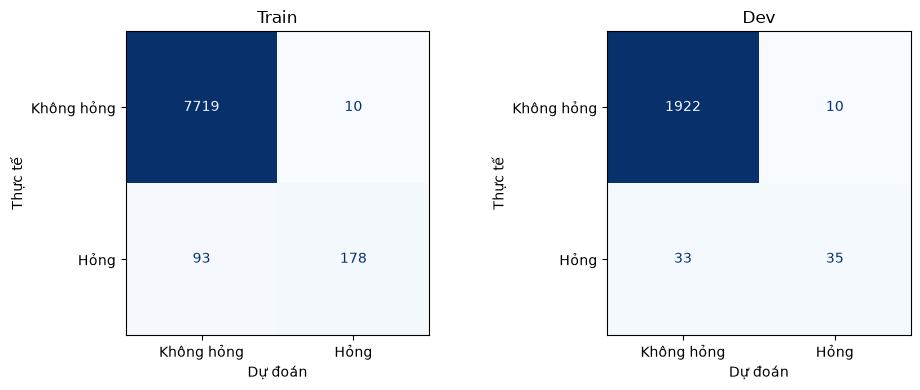

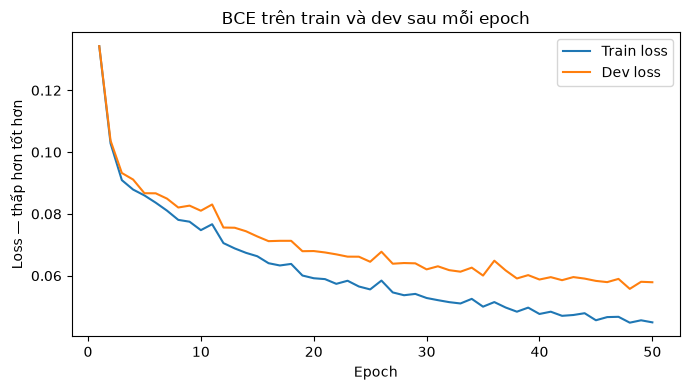

In [7]:
model.eval()
with torch.no_grad():
    train_scores = model(X_train_tensor)
    dev_scores = model(X_dev_tensor)

train_pred = (train_scores.numpy().ravel() >= THRESHOLD).astype(int)
dev_pred = (dev_scores.numpy().ravel() >= THRESHOLD).astype(int)

def calculate_metrics(labels, predicted):
    return {
        "Accuracy": accuracy_score(labels, predicted),
        "Precision (hỏng)": precision_score(labels, predicted, zero_division=0),
        "Recall (hỏng)": recall_score(labels, predicted, zero_division=0),
    }

results = pd.DataFrame({
    "Train": {"Loss (BCE)": loss_function(train_scores, y_train_tensor).item(),
              **calculate_metrics(y_train, train_pred)},
    "Dev": {"Loss (BCE)": loss_function(dev_scores, y_dev_tensor).item(),
            **calculate_metrics(y_dev, dev_pred)},
}).T
display(results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, labels, predicted in [
    (axes[0], "Train", y_train, train_pred),
    (axes[1], "Dev", y_dev, dev_pred),
]:
    ConfusionMatrixDisplay.from_predictions(
        labels, predicted, labels=[0, 1], display_labels=["Không hỏng", "Hỏng"],
        ax=ax, colorbar=False, cmap="Blues",
    )
    ax.set(title=name, xlabel="Dự đoán", ylabel="Thực tế")
plt.tight_layout()
plt.show()

loss_history = pd.DataFrame(history).set_index("Epoch")
loss_history.plot(figsize=(7, 4), title="BCE trên train và dev sau mỗi epoch")
plt.ylabel("Loss — thấp hơn tốt hơn")
plt.tight_layout()
plt.show()

## 6. Metrics phù hợp phát hiện máy hỏng.

Recall, vì giả sử model luôn đoán máy không hỏng thì precision vẫn rất cao do chênh lệch nhãn dữ liệu.

